# Homework 0 | An Introduction To Python & The Four Horseman

My least favorite things about the classes I take now is that every professor seems to have the desire to want to teach Python over and over again completely from scratch. Luckily, I know you are all pretty smart, and I figured just throwing you guys into the deep end is probably the best way to get familar with Python and it's beautiful packages. Also, AI exists, which helps considerably.

Below are some introductory tasks that I think will get you very quickly familar with Python. Give them a go and try to rely on AI as minimally as possible - what I mean by that is, I expect that with practice, you should be able to do these things from memory + with your own thinking.

### 1. Stock Price Dashboard

Pull: Use yfinance to download daily data for a few tickers (e.g., AAPL, MSFT, TSLA).

Transform: Compute moving averages (20-day, 50-day, 200-day).

Plot: For each stock (on a seperate plot), overlay price and moving averages on a line chart. Hint: use matplotlib subplots

Extension: Compare multiple stocks on the same chart with normalized returns (so they start at 100).

### 2. Volatility & Returns Analysis

Pull: Grab 1–2 years of data for an ETF (like SPY).

Transform: Calculate daily returns, cumulative returns, and rolling volatility using returns and log returns. Hint: use .pct_change()

Plot:
* Histogram of daily returns (seaborn is great here).
* Rolling volatility over time.
* Cumulative return curve.

Extension: Compare volatility between two stocks or sectors.

### 3. Sector Comparison Project

Pull: Download sector ETFs (XLK, XLE, XLF, etc.) for the past 5 years.

Transform: Compute annualized returns and Sharpe ratios.

Plot:
* Heatmap of correlations between sector returns.
* Bar chart comparing average returns and volatilities.

Extension: Add rolling correlation plots (e.g., XLK vs SPY over time).

## Tips

* Use the yfinance package to pull data
* there is probably a function for "it" in pandas somewhere...
* Don't mess up!

## Your work starts here

In [44]:
import numpy as np 
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [16]:
#pull data from yfinance
tickers = ['AAPL', 'MSFT', 'TSLA']

data = {}
for t in tickers:
    df = yf.download(t, period='2y')
    data[t] = df
    
    

/var/folders/pj/1wf8h2rx47nf6pwhy55jvs2c0000gn/T/ipykernel_37698/2846834398.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(t, period='2y')
[*********************100%***********************]  1 of 1 completed
/var/folders/pj/1wf8h2rx47nf6pwhy55jvs2c0000gn/T/ipykernel_37698/2846834398.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(t, period='2y')
[*********************100%***********************]  1 of 1 completed
/var/folders/pj/1wf8h2rx47nf6pwhy55jvs2c0000gn/T/ipykernel_37698/2846834398.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(t, period='2y')
[*********************100%***********************]  1 of 1 completed


In [17]:
#testing
print(data.keys()) 

dict_keys(['AAPL', 'MSFT', 'TSLA'])


In [18]:
#testing
print(data['AAPL'].head())

Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2023-09-13  172.520203  175.580227  172.292423  174.797881   84267900
2023-09-14  174.035355  174.391863  171.896303  172.312227   60895800
2023-09-15  173.312408  174.787961  172.133964  174.768151  109259500
2023-09-18  176.243683  177.640009  174.461140  174.768130   67257600
2023-09-19  177.333038  177.887604  175.411854  175.798070   51826900


In [23]:
#moving averages
for t in tickers:
    df = data[t]
    df['MA20'] = df['Close'].rolling(window=20).mean()
    df['MA50'] = df['Close'].rolling(window=50).mean()
    df['MA200'] = df['Close'].rolling(window=200).mean()
    data[t] = df  # Save the updated df back to the dictionary

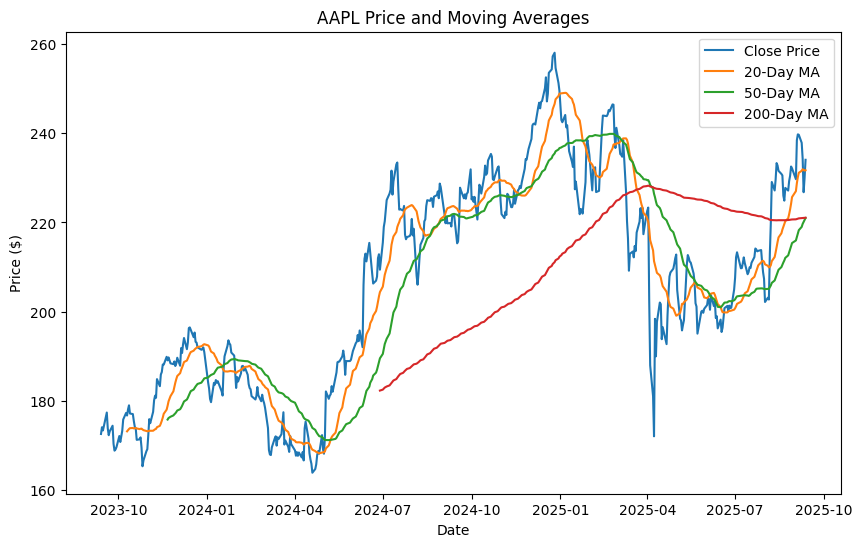

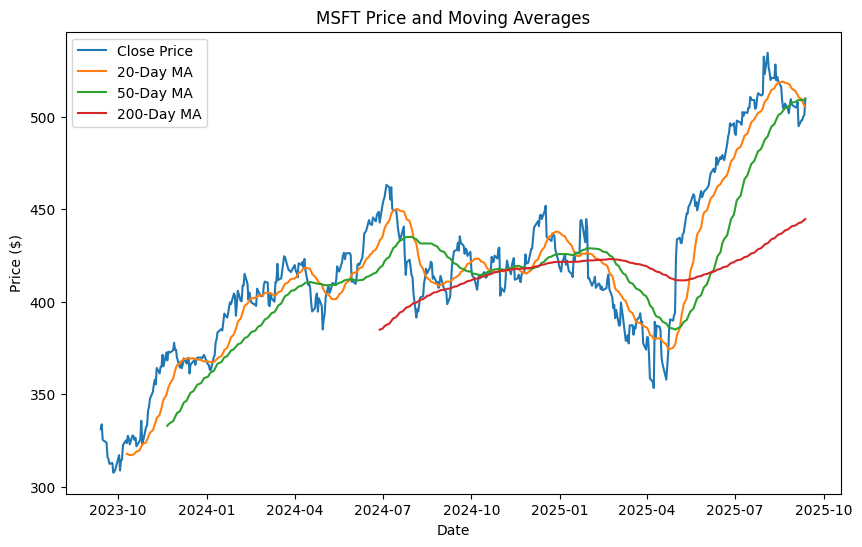

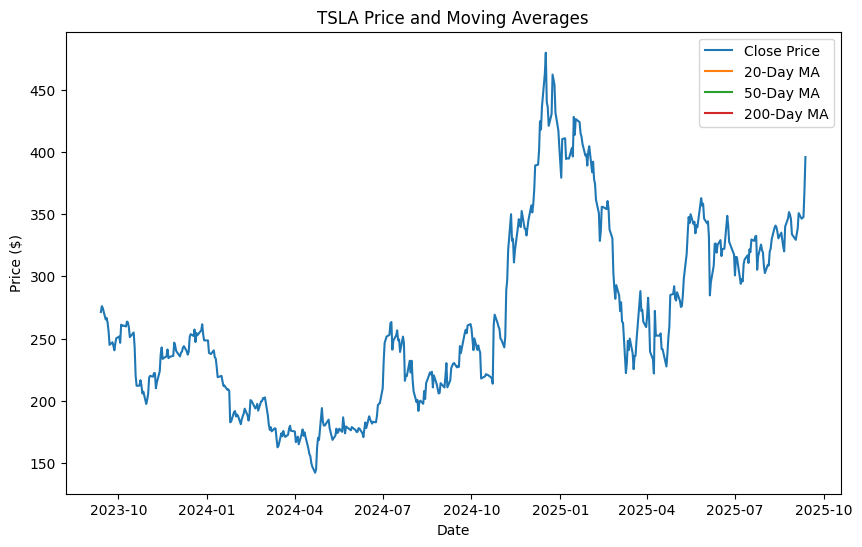

In [24]:

#plot 
for t in tickers:
    df = data[t]
    plt.figure(figsize=(10,6))
    plt.plot(df['Close'], label='Close Price')
    plt.plot(df['MA20'], label='20-Day MA')
    plt.plot(df['MA50'], label='50-Day MA')
    plt.plot(df['MA200'], label='200-Day MA')
    plt.title(f'{t} Price and Moving Averages')
    plt.xlabel('Date')
    plt.ylabel('Price ($)')
    plt.legend()
    plt.show()

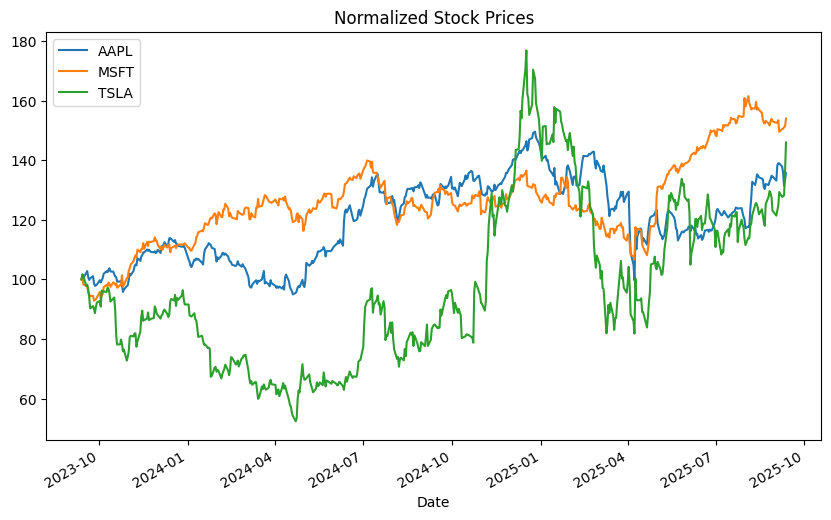

In [ ]:
#normalized stock prices
#rescale all stocks to start at 100 - Normalized price = Price(t)/Price(0) * 100 (percentage growths are shown)


combined = pd.concat([data[t]["Close"]/data[t]["Close"].iloc[0]*100 for t in tickers], axis=1)
combined.columns = tickers
combined.plot(figsize=(10,6))
plt.title('Normalized Stock Prices')
plt.show()

In [37]:
# #2 
#pull data (spy etf)
spy = yf.download('SPY', period='2y')
print(spy.head())

/var/folders/pj/1wf8h2rx47nf6pwhy55jvs2c0000gn/T/ipykernel_37698/4096202169.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spy = yf.download('SPY', period='2y')
[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open     Volume
Ticker             SPY         SPY         SPY         SPY        SPY
Date                                                                 
2023-09-13  434.933502  436.102372  433.540555  434.651013   60199300
2023-09-14  438.683655  439.384989  436.112117  437.427122   83430800
2023-09-15  433.398254  437.415833  432.958393  437.083483  111848900
2023-09-18  433.652405  434.962264  432.606463  433.085433   55752200
2023-09-19  432.753052  433.320024  430.045362  432.723728   66514600


In [38]:
#Daily return
spy['Daily Return'] = spy['Close'].pct_change()

In [ ]:
#Log return 
spy['Log Return'] = np.log(spy['Close']/spy['Close'].shift(1))

In [ ]:
#cumulative return
#cumprod = cumulative product over time
spy['Cumulative Return'] = (1 + spy['Daily Return']).cumprod()

In [41]:
#rolling volatility -moving std dev of daily returns; 21 days = 1 trading month
spy['Rolling Volatility'] = spy['Daily Return'].rolling(window=21).std()

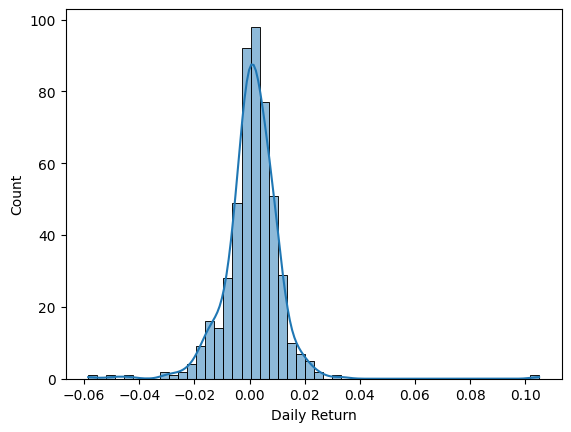

In [ ]:
#historgram of daily returns
sns.histplot(spy['Daily Return'].dropna(), bins=50, kde=True)
plt.show()
#rare extreme days - most are around 0 aka SPY changes by less than 1% on most days

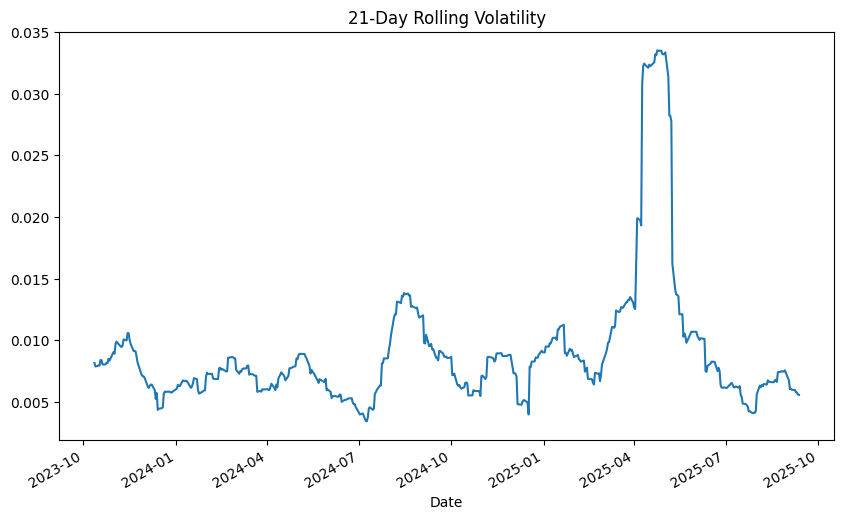

In [46]:
#rolling volatility over time
spy['Rolling Volatility'].plot(figsize=(10,6), title='21-Day Rolling Volatility')
plt.show()

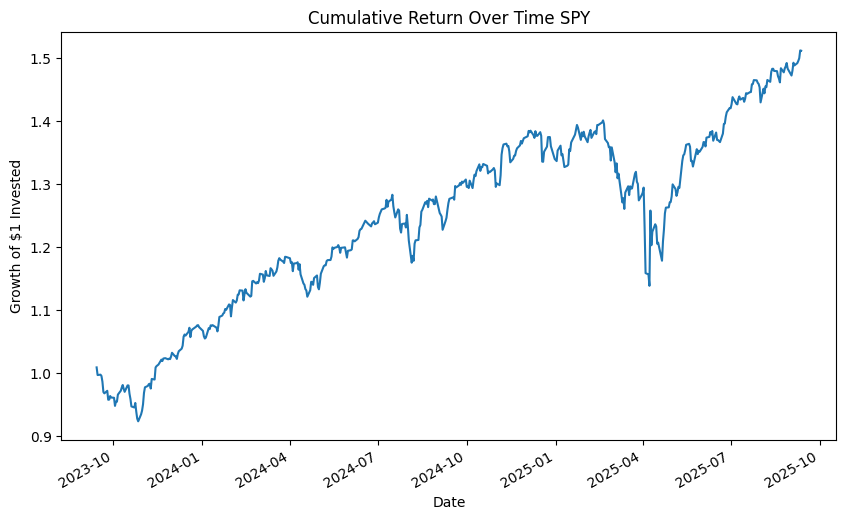

In [ ]:
#cumulative return curve
spy['Cumulative Return'].plot(figsize=(10,6), title='Cumulative Return Over Time SPY')
plt.ylabel("Growth of $1 Invested")
plt.show()
#how $1 has grown over time

In [48]:
#Compare volatility of different stocks
tickers = ['SPY','QQQ']
data = yf.download(tickers, period='2y')['Close']
returns = data.pct_change()



/var/folders/pj/1wf8h2rx47nf6pwhy55jvs2c0000gn/T/ipykernel_37698/182644494.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, period='2y')['Close']
[*********************100%***********************]  2 of 2 completed


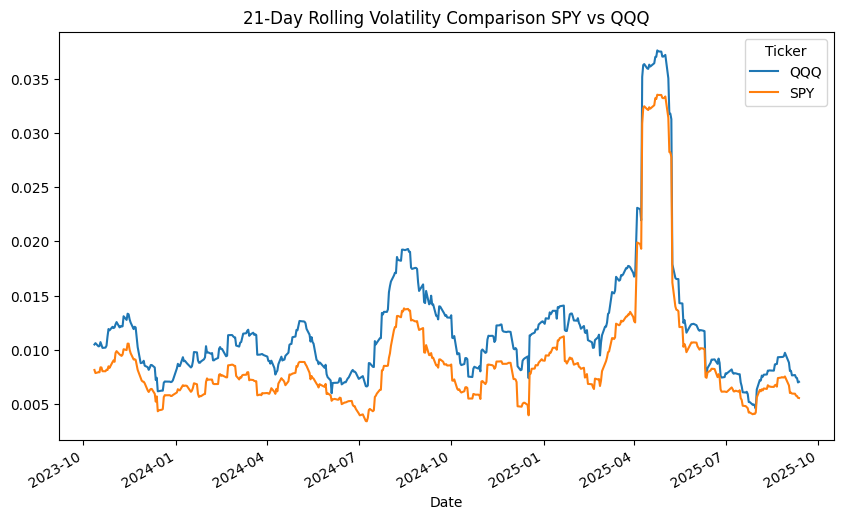

In [49]:
#rolling volatility
rolling_vol = returns.rolling(window=21).std()
rolling_vol.plot(figsize=(10,6), title='21-Day Rolling Volatility Comparison SPY vs QQQ')
plt.show()

In [ ]:
#pull sector etf data
#tech, finance, energy, healthcare, consumer discretionary
tickers = ["XLK", "XLF","XLE", "XLV", "XLY"]
data = yf.download(tickers, period='2y')['Close']


/var/folders/pj/1wf8h2rx47nf6pwhy55jvs2c0000gn/T/ipykernel_37698/3772448024.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, period='2y')['Close']
[*********************100%***********************]  5 of 5 completed


In [51]:
#daily returns
returns = data.pct_change().dropna()

In [52]:
#annualized return - how much would you have made over a year if you held the stock
#annualized volatility - how volatile is the stock over a year
#sharpe ratio - measure of return per unit of risk (higher is better); efficiency 

metrics = {}
for t in tickers:
    mean_daily = returns[t].mean()
    std_daily = returns[t].std()
    
    annualized_return = (1 + mean_daily)**252 - 1
    annualized_vol = std_daily * np.sqrt(252)
    sharpe_ratio = annualized_return / annualized_vol
    metrics[t] = {
        'Annualized Return': annualized_return,
        'Annualized Volatility': annualized_vol,
        'Sharpe Ratio': sharpe_ratio
    }
    
metrics_df = pd.DataFrame(metrics).T
print(metrics_df)

     Annualized Return  Annualized Volatility  Sharpe Ratio
XLK           0.308037               0.244893      1.257842
XLF           0.285393               0.168903      1.689683
XLE           0.037177               0.218638      0.170037
XLV           0.047181               0.140532      0.335734
XLY           0.213500               0.217926      0.979691


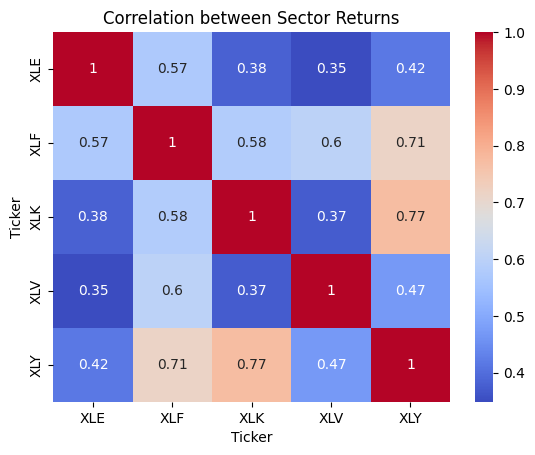

In [53]:
#heatmap of correlation
sns.heatmap(returns.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation between Sector Returns")
plt.show()

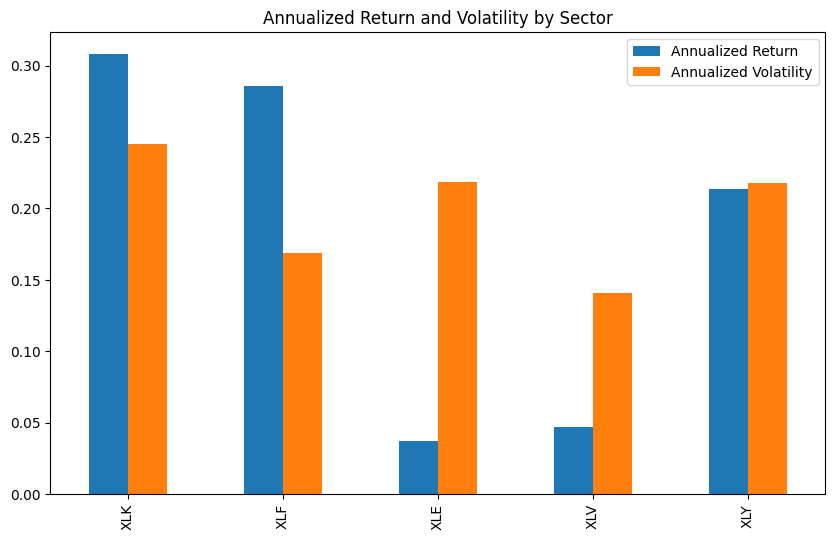

In [54]:
#bar chart of returns and volatility
metrics_df[['Annualized Return', 'Annualized Volatility']].plot(kind='bar', figsize=(10,6))
plt.title("Annualized Return and Volatility by Sector")
plt.show()

Graph analysis: 

XLK - tech is high return but also high volatile aka rewarding but risky
XKL - financials have a high return and slightly lower volatility aka rewarding and moderate risk
XLE - energy has small returns and is highly volatile aka low reward and high risk
XLV - healthcare has a low return and low ish volatility aka low reward and fairly low volatility
XLY - Consumer discretionary has a moderate return and moderate risk aka decent reward and a solid amount of risk

/var/folders/pj/1wf8h2rx47nf6pwhy55jvs2c0000gn/T/ipykernel_37698/823749579.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data2 = yf.download(tickers2, period='2y')['Close']
[*********************100%***********************]  2 of 2 completed


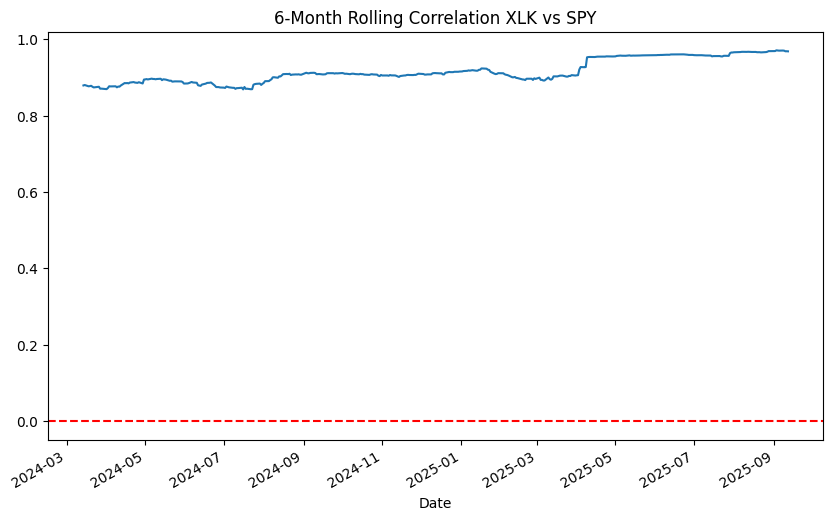

In [57]:
#rolling correlation XLK vs SPY for 6 months

tickers2 = ['XLK', "SPY"]
data2 = yf.download(tickers2, period='2y')['Close']
returns2 = data2.pct_change().dropna()
rolling_corr = returns2['XLK'].rolling(window=126).corr(returns2['SPY'])

rolling_corr.plot(figsize=(10,6), title='6-Month Rolling Correlation XLK vs SPY')
plt.axhline(0, color='red', linestyle='--')
plt.show()